# SafePredict-XAI: Phase 2 — Data Validation & Clinical Quality Pipeline

**Project:** SafePredict-XAI  
**Role:** Healthcare Data Scientist  
**Objective:** Build a robust, production-grade clinical data-validation pipeline before performing cleaning, feature engineering, or model training.

---

### Core Principles of Clinical Data Validation:
1. **Separation of Concerns:** Distinctly separate **Technical Validation** (schemas, keys, orphan records, types) from **Clinical / Plausibility Validation** (physiological boundaries, negative values, target validity).
2. **No Silent Data Deletion:** Bad, missing, or outlier records are **flagged and documented**, never silently dropped.
3. **Documented Clinical Thresholds:** All plausibility ranges cite established clinical references (AHA/ACLS, Surviving Sepsis, West's Physiology, Marino's ICU Book, Tietz Clinical Chemistry) rather than arbitrary guesses.
4. **Encounter-Level Quality Profiling:** Compute explicit boolean data-quality flags per ICU encounter (`patientunitstayid`).


## 1. Schema Validation & Ingestion

We verify that all required columns exist and fail clearly if any essential schema contracts are violated:
- `patient.csv`: `patientunitstayid`, `age`, `gender`, `hospitaldischargestatus`
- `lab.csv`: `patientunitstayid`, `labresultoffset`, `labname`, `labresult`
- `vitalPeriodic.csv`: `patientunitstayid`, `observationoffset`


In [5]:
import sys
import os
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Import our production validation module
if Path("src").exists():
    sys.path.insert(0, ".")
elif Path("../src").exists():
    sys.path.insert(0, "..")

from src.validation import (
    validate_schemas,
    validate_identifiers,
    validate_targets,
    validate_temporal_windows,
    validate_missingness,
    validate_clinical_plausibility,
    generate_data_quality_flags,
    add_temporal_flags,
    DEFAULT_VITAL_PLAUSIBILITY_BOUNDS,
    DEFAULT_LAB_PLAUSIBILITY_BOUNDS
)

# Robust path resolution
base_dir = Path("..") if Path("../data/raw").exists() else Path(".")
data_dir = base_dir / "data" / "raw"

# Load raw datasets using Polars
patient = pl.read_csv(data_dir / "patient.csv")
lab = pl.read_csv(data_dir / "lab.csv")
vital = pl.read_csv(data_dir / "vitalPeriodic.csv")

print("Raw Datasets Loaded:")
print(f"  • patient.csv:        {patient.height:,} rows x {patient.width} cols")
print(f"  • lab.csv:            {lab.height:,} rows x {lab.width} cols")
print(f"  • vitalPeriodic.csv:  {vital.height:,} rows x {vital.width} cols")


Raw Datasets Loaded:
  • patient.csv:        2,520 rows x 29 cols
  • lab.csv:            434,660 rows x 10 cols
  • vitalPeriodic.csv:  1,634,960 rows x 19 cols


In [6]:
# Execute Schema Validation
schema_report = validate_schemas(patient, lab, vital, strict=True)
print("Schema Validation Status:", schema_report["status"])
print("-" * 65)
for tbl in ["patient", "lab", "vitalPeriodic"]:
    info = schema_report[tbl]
    print(f"Table: {tbl:<16} | Checked: {len(info['required_columns_checked'])} cols | Missing: {info['missing_required_columns']} | Status: {'PASS' if info['passed'] else 'FAIL'}")


Schema Validation Status: PASS
-----------------------------------------------------------------
Table: patient          | Checked: 4 cols | Missing: [] | Status: PASS
Table: lab              | Checked: 4 cols | Missing: [] | Status: PASS
Table: vitalPeriodic    | Checked: 2 cols | Missing: [] | Status: PASS


## 2. Identifier Validation & Relational Integrity

We validate:
- Missing `patientunitstayid` (must be 0 across all tables)
- Duplicate `patientunitstayid` in `patient.csv` (must be 0, ensuring 1-to-1 primary key)
- Orphan records in `lab.csv` and `vitalPeriodic.csv` (foreign keys not present in `patient.csv`)
- Repeated measurements (same stay, test/timestamp)


In [7]:
# Execute Identifier Validation
id_report = validate_identifiers(patient, lab, vital)

print("Identifier & Relational Integrity Report:")
print("=" * 75)
print("1. Missing patientunitstayid:")
for tbl, ct in id_report["missing_patientunitstayid"].items():
    print(f"   • {tbl:<16}: {ct} nulls")

print()
print(f"2. Duplicate patientunitstayid in patient.csv: {id_report['patient_primary_key_duplicates']}")

print()
print("3. Orphan Records (Foreign keys not found in patient.csv):")
print(f"   • lab.csv orphan records:           {id_report['orphan_records']['lab_orphan_records']}")
print(f"   • vitalPeriodic.csv orphan records: {id_report['orphan_records']['vital_orphan_records']}")

print()
print("4. Repeated Measurements / Timestamps:")
print(f"   • Repeated lab measurements (same stay, test, offset): {id_report['repeated_measurements']['repeated_lab_measurements']:,} ({id_report['repeated_measurements']['repeated_lab_pct']:.2f}%)")
print(f"   • Repeated vital timestamps (same stay, offset):       {id_report['repeated_measurements']['repeated_vital_timestamps']:,} ({id_report['repeated_measurements']['repeated_vital_pct']:.2f}%)")
print(f"   • Clinical Interpretation: {id_report['repeated_measurements']['clinical_note']}")


Identifier & Relational Integrity Report:
1. Missing patientunitstayid:
   • patient         : 0 nulls
   • lab             : 0 nulls
   • vital           : 0 nulls

2. Duplicate patientunitstayid in patient.csv: 0

3. Orphan Records (Foreign keys not found in patient.csv):
   • lab.csv orphan records:           0
   • vitalPeriodic.csv orphan records: 0

4. Repeated Measurements / Timestamps:
   • Repeated lab measurements (same stay, test, offset): 2,267 (0.52%)
   • Repeated vital timestamps (same stay, offset):       2 (0.00%)
   • Clinical Interpretation: Repeated lab and vital timestamps reflect simultaneous multi-channel telemetry or duplicate blood draw tube orders; they are not inherently corrupted records.


## 3. Target Outcome Validation (`hospitaldischargestatus`)

We validate the primary clinical prediction outcome:
- **`Alive` $\longrightarrow 0$** (Surviving the hospital admission)
- **`Expired` $\longrightarrow 1$** (In-hospital death)
- **`Missing` / `""` $\longrightarrow$ Unrecorded outcome**

**Clinical Safeguard:**
> [!IMPORTANT]
> `hospitaldischargestatus` is the ground-truth prediction target. It must **NEVER** be included as a predictor in feature matrices.


In [8]:
# Execute Target Validation
target_report = validate_targets(patient)

print("Target Validation Summary:")
print("=" * 65)
print(f"Total Stays: {target_report['total_encounters']:,}")
for cat, count in target_report["counts"].items():
    pct = target_report["percentages"].get(cat.split(" ")[0], count / target_report["total_encounters"] * 100)
    print(f"  • {cat:<24}: {count:>5} ({pct:>5.2f}%)")

print()
print(f"Known Outcomes Total: {target_report['known_outcomes_total']:,}")
print(f"In-Hospital Mortality Prevalence: {target_report['mortality_prevalence_pct']:.2f}%")
print(f"Clinical Safeguard: {target_report['clinical_safeguard']}")


Target Validation Summary:
Total Stays: 2,520
  • Alive (0)               :  2280 (90.48%)
  • Expired (1)             :   212 ( 8.41%)
  • Missing / Unrecorded    :    28 ( 1.11%)
  • Other / Invalid         :     0 ( 0.00%)

Known Outcomes Total: 2,492
In-Hospital Mortality Prevalence: 8.51%
Clinical Safeguard: hospitaldischargestatus is the ground truth target; it must NEVER be included as a feature in any training matrix.


## 4. Temporal Validation & Observation Windows

In intensive care prediction models, observation timing is critical to prevent **lookahead bias / data leakage**:
- **`pre_icu` ($	ext{offset} < 0$):** Emergency department, triage, or pre-admission labs/vitals.
- **`first_24h` ($0 \le 	ext{offset} \le 1440$):** **Primary clinical observation window** for early mortality risk prediction.
- **`post_24h` ($	ext{offset} > 1440$):** Subsequent days of ICU stay (must be excluded from early prediction features).

We add temporal window boolean flags to records **without deleting any raw data**.


In [9]:
# Execute Temporal Window Validation
temporal_report = validate_temporal_windows(lab, vital)

# Display summary table
temp_summary_df = pl.DataFrame({
    "Observation Window": ["Pre-ICU (< 0 min)", "First 24 Hours (0 - 1440 min) [Target]", "Post 24 Hours (> 1440 min)", "Total Records"],
    "Lab Records": [
        f"{temporal_report['lab_temporal_summary']['pre_icu_count']:,} ({temporal_report['lab_temporal_summary']['pre_icu_pct']:.2f}%)",
        f"{temporal_report['lab_temporal_summary']['first_24h_count']:,} ({temporal_report['lab_temporal_summary']['first_24h_pct']:.2f}%)",
        f"{temporal_report['lab_temporal_summary']['post_24h_count']:,} ({temporal_report['lab_temporal_summary']['post_24h_pct']:.2f}%)",
        f"{temporal_report['lab_temporal_summary']['total_records']:,} (100.0%)"
    ],
    "Vital Records": [
        f"{temporal_report['vital_temporal_summary']['pre_icu_count']:,} ({temporal_report['vital_temporal_summary']['pre_icu_pct']:.2f}%)",
        f"{temporal_report['vital_temporal_summary']['first_24h_count']:,} ({temporal_report['vital_temporal_summary']['first_24h_pct']:.2f}%)",
        f"{temporal_report['vital_temporal_summary']['post_24h_count']:,} ({temporal_report['vital_temporal_summary']['post_24h_pct']:.2f}%)",
        f"{temporal_report['vital_temporal_summary']['total_records']:,} (100.0%)"
    ]
})

print("Temporal Window Summary:")
print(temp_summary_df)


Temporal Window Summary:
shape: (4, 3)
┌─────────────────────────────────┬──────────────────┬────────────────────┐
│ Observation Window              ┆ Lab Records      ┆ Vital Records      │
│ ---                             ┆ ---              ┆ ---                │
│ str                             ┆ str              ┆ str                │
╞═════════════════════════════════╪══════════════════╪════════════════════╡
│ Pre-ICU (< 0 min)               ┆ 97,488 (22.43%)  ┆ 1,650 (0.10%)      │
│ First 24 Hours (0 - 1440 min) … ┆ 98,870 (22.75%)  ┆ 553,846 (33.88%)   │
│ Post 24 Hours (> 1440 min)      ┆ 238,302 (54.82%) ┆ 1,079,464 (66.02%) │
│ Total Records                   ┆ 434,660 (100.0%) ┆ 1,634,960 (100.0%) │
└─────────────────────────────────┴──────────────────┴────────────────────┘


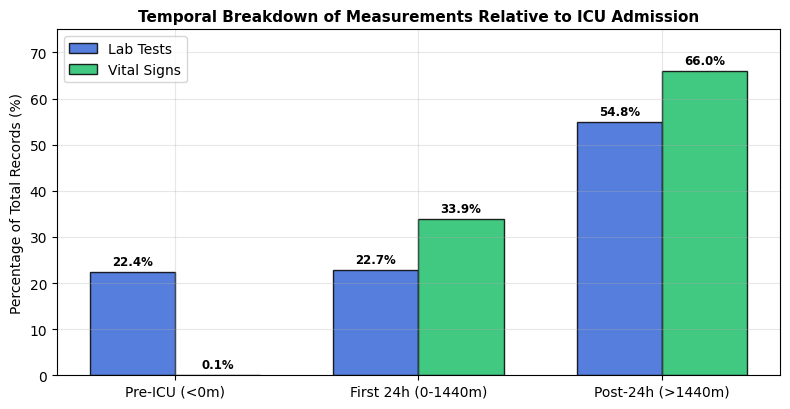

In [10]:
# Visualize temporal window distribution
fig, ax = plt.subplots(figsize=(8, 4.2))

windows = ["Pre-ICU (<0m)", "First 24h (0-1440m)", "Post-24h (>1440m)"]
lab_pcts = [
    temporal_report['lab_temporal_summary']['pre_icu_pct'],
    temporal_report['lab_temporal_summary']['first_24h_pct'],
    temporal_report['lab_temporal_summary']['post_24h_pct']
]
vital_pcts = [
    temporal_report['vital_temporal_summary']['pre_icu_pct'],
    temporal_report['vital_temporal_summary']['first_24h_pct'],
    temporal_report['vital_temporal_summary']['post_24h_pct']
]

x = np.arange(len(windows))
w = 0.35

rects1 = ax.bar(x - w/2, lab_pcts, w, label="Lab Tests", color="#3867d6", edgecolor="black", alpha=0.85)
rects2 = ax.bar(x + w/2, vital_pcts, w, label="Vital Signs", color="#20bf6b", edgecolor="black", alpha=0.85)

ax.set_title("Temporal Breakdown of Measurements Relative to ICU Admission", fontsize=11, fontweight="bold")
ax.set_ylabel("Percentage of Total Records (%)")
ax.set_xticks(x)
ax.set_xticklabels(windows)
ax.legend()
ax.set_ylim(0, 75)

for rect in rects1 + rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Missingness Validation & Informative Missingness

We calculate missingness percentages across demographic attributes, laboratory tests, and vital signs.

> [!WARNING]
> **Complete-case deletion must NOT be performed.** In the ICU, missingness is **Missing Not at Random (MNAR)**: diagnostic tests and invasive lines are ordered based on clinical suspicion. Deleting rows with missing measurements introduces severe selection bias and destroys predictive signal.


In [11]:
# Execute Missingness Profiling
missing_report = validate_missingness(patient, lab, vital)

# Convert patient missingness to DataFrame
patient_miss_list = [
    {"Feature": col, "Null Count": v["null_count"], "Missing (%)": f"{v['missing_pct']:.2f}%"}
    for col, v in missing_report["patient_missingness"].items()
    if v["null_count"] > 0
]
patient_miss_df = pl.DataFrame(patient_miss_list).sort("Null Count", descending=True)

# Convert vital missingness to DataFrame
vital_miss_list = [
    {"Vital Sign": col, "Null Count": v["null_count"], "Missing (%)": f"{v['missing_pct']:.2f}%"}
    for col, v in missing_report["vital_missingness"].items()
]
vital_miss_df = pl.DataFrame(vital_miss_list).sort("Null Count", descending=True)

print("Demographic & Admission Missingness (Non-zero):")
print(patient_miss_df)
print()
print("Vital Signs Stream Missingness:")
print(vital_miss_df)


Demographic & Admission Missingness (Non-zero):
shape: (13, 3)
┌───────────────────────┬────────────┬─────────────┐
│ Feature               ┆ Null Count ┆ Missing (%) │
│ ---                   ┆ ---        ┆ ---         │
│ str                   ┆ i64        ┆ str         │
╞═══════════════════════╪════════════╪═════════════╡
│ dischargeweight       ┆ 1284       ┆ 50.95%      │
│ hospitaladmitsource   ┆ 594        ┆ 23.57%      │
│ apacheadmissiondx     ┆ 299        ┆ 11.87%      │
│ admissionweight       ┆ 198        ┆ 7.86%       │
│ admissionheight       ┆ 69         ┆ 2.74%       │
│ …                     ┆ …          ┆ …           │
│ unitadmitsource       ┆ 22         ┆ 0.87%       │
│ gender                ┆ 4          ┆ 0.16%       │
│ age                   ┆ 4          ┆ 0.16%       │
│ unitdischargelocation ┆ 4          ┆ 0.16%       │
│ unitdischargestatus   ┆ 2          ┆ 0.08%       │
└───────────────────────┴────────────┴─────────────┘

Vital Signs Stream Missingness:
sha

## 6. Value & Clinical Plausibility Validation

We evaluate numeric physiological features against established clinical boundaries:
- Negative values where physically/biologically inappropriate (e.g., negative blood pressures or negative lab concentrations).
- Extreme / impossible values representing transducer zeroing artifacts, sensor disconnects, or data entry errors.

### Documented Clinical Reference Ranges:
| Variable | Plausibility Range | Documented Clinical Rationale & Source |
| :--- | :--- | :--- |
| **Heart Rate** | 20 – 250 bpm | *AHA / ACLS Guidelines*: <20 bpm (severe bradycardia/peri-arrest/lead off), >250 bpm (extreme tachyarrhythmia/artifact). |
| **SaO2 / SpO2** | 50 – 100 % | *West's Respiratory Physiology*: >100% physically impossible; <50% severe hypoxemia or probe detachment. |
| **Respiration Rate** | 4 – 70 bpm | *Marino's The ICU Book*: <4 bpm severe central hypoventilation/apnea; >70 bpm ventilator/chest motion artifact. |
| **Temperature** | 28.0 – 43.0 °C | *Emergency Medicine Hypothermia/Hyperthermia Guidelines*: Core temp outside 28–43°C represents profound hypothermia or fatal hyperthermia/probe error. |
| **Invasive Systolic BP** | 30 – 300 mmHg | *Arterial Line Guidelines*: Negative values represent calibration zeroing drift or pressure bag flush artifacts. |
| **Invasive Diastolic BP** | 10 – 200 mmHg | *Arterial Line Guidelines*: Negative values represent transducer artifacts; must be lower than systolic. |
| **Invasive Mean BP (MAP)**| 20 – 250 mmHg | *Surviving Sepsis Guidelines*: MAP <20 mmHg indicates profound circulatory collapse / line error. |
| **Serum Glucose** | 10 – 1500 mg/dL | *Tietz Textbook of Clinical Chemistry*: Severe hypoglycemia to profound DKA/HHS. |
| **Potassium** | 1.0 – 10.0 mmol/L | *Tietz Clinical Chemistry*: Severe hypokalemia to fatal hyperkalemia / hemolysis. |
| **Sodium** | 100 – 180 mmol/L | *Tietz Clinical Chemistry*: Profound hyponatremia to severe hypernatremia. |
| **Creatinine** | 0.1 – 30.0 mg/dL | *Tietz Clinical Chemistry*: Standard range to end-stage renal failure / anuria. |
| **White Blood Cells (WBC)**| 0.1 – 200.0 K/uL | *Tietz Clinical Chemistry*: Profound leukopenia to leukemoid reaction / leukemia. |


In [12]:
# Execute Clinical Plausibility Validation
plausibility_report = validate_clinical_plausibility(vital, lab)

# Format Vital Plausibility Table
vital_plaus_rows = []
for var, info in plausibility_report["vital_plausibility"].items():
    vital_plaus_rows.append({
        "Vital Variable": var,
        "Valid Bounds": f"[{info['plausibility_range'][0]}, {info['plausibility_range'][1]}]",
        "Total Non-Null": f"{info['total_non_null']:,}",
        "Negative Count": info["negative_count"],
        "Out-of-Bounds Count": f"{info['out_of_bounds_count']:,}",
        "Out-of-Bounds (%)": f"{info['out_of_bounds_pct']:.2f}%",
    })
vital_plaus_df = pl.DataFrame(vital_plaus_rows)

print("Vital Sign Physiological Plausibility Audit:")
print(vital_plaus_df)


Vital Sign Physiological Plausibility Audit:
shape: (7, 6)
┌─────────────────┬───────────────┬───────────┬─────────────────┬─────────────────┬────────────────┐
│ Vital Variable  ┆ Valid Bounds  ┆ Total     ┆ Negative Count  ┆ Out-of-Bounds   ┆ Out-of-Bounds  │
│ ---             ┆ ---           ┆ Non-Null  ┆ ---             ┆ Count           ┆ (%)            │
│ str             ┆ str           ┆ ---       ┆ i64             ┆ ---             ┆ ---            │
│                 ┆               ┆ str       ┆                 ┆ str             ┆ str            │
╞═════════════════╪═══════════════╪═══════════╪═════════════════╪═════════════════╪════════════════╡
│ heartrate       ┆ [20.0, 250.0] ┆ 1,627,894 ┆ 0               ┆ 370             ┆ 0.02%          │
│ sao2            ┆ [50.0, 100.0] ┆ 1,441,700 ┆ 0               ┆ 1,985           ┆ 0.14%          │
│ respiration     ┆ [4.0, 70.0]   ┆ 1,381,351 ┆ 0               ┆ 13,647          ┆ 0.99%          │
│ temperature     ┆ [28.0, 43.0]

In [13]:
# Format Lab Plausibility Table
lab_plaus_rows = []
for test_name, info in plausibility_report["lab_plausibility"].items():
    lab_plaus_rows.append({
        "Lab Test Name": test_name,
        "Valid Bounds": f"[{info['plausibility_range'][0]}, {info['plausibility_range'][1]}]",
        "Total Non-Null": f"{info['total_non_null']:,}",
        "Negative Count": info["negative_count"],
        "Out-of-Bounds Count": f"{info['out_of_bounds_count']:,}",
        "Out-of-Bounds (%)": f"{info['out_of_bounds_pct']:.2f}%",
    })
lab_plaus_df = pl.DataFrame(lab_plaus_rows)

print("Laboratory Test Physiological Plausibility Audit:")
print(lab_plaus_df)


Laboratory Test Physiological Plausibility Audit:
shape: (11, 6)
┌─────────────────┬─────────────────┬──────────┬─────────────────┬────────────────┬────────────────┐
│ Lab Test Name   ┆ Valid Bounds    ┆ Total    ┆ Negative Count  ┆ Out-of-Bounds  ┆ Out-of-Bounds  │
│ ---             ┆ ---             ┆ Non-Null ┆ ---             ┆ Count          ┆ (%)            │
│ str             ┆ str             ┆ ---      ┆ i64             ┆ ---            ┆ ---            │
│                 ┆                 ┆ str      ┆                 ┆ str            ┆ str            │
╞═════════════════╪═════════════════╪══════════╪═════════════════╪════════════════╪════════════════╡
│ bedside glucose ┆ [10.0, 1500.0]  ┆ 29,900   ┆ 0               ┆ 0              ┆ 0.00%          │
│ glucose         ┆ [10.0, 1500.0]  ┆ 14,980   ┆ 0               ┆ 0              ┆ 0.00%          │
│ potassium       ┆ [1.0, 10.0]     ┆ 16,335   ┆ 0               ┆ 0              ┆ 0.00%          │
│ sodium          ┆ [100.0

## 7. Encounter-Level Data Quality Flags

We aggregate validation findings into explicit boolean flags per ICU stay (`patientunitstayid`):
1. **`flag_missing_demographics`**: Missing age, gender, or ethnicity.
2. **`flag_missing_target`**: Missing or blank hospital discharge status.
3. **`flag_missing_lab_data`**: 0 lab measurements in the 24-hour observation window.
4. **`flag_missing_vital_data`**: 0 vital measurements in the 24-hour observation window.
5. **`flag_temporal_issue`**: 0 data across both labs and vitals in the 24-hour window.
6. **`flag_possible_invalid_value`**: At least one out-of-plausibility lab or vital measurement in the 24-hour window.

> [!NOTE]
> We do NOT create an arbitrary "validated clinical quality score". We include a simple `experimental_completeness_pct` [0–100%] strictly designated as an **experimental** research indicator.


In [14]:
# Generate encounter-level quality flags
quality_flags = generate_data_quality_flags(patient, lab, vital)

print("Encounter-Level Data Quality Summary (2,520 ICU Encounters):")
print("=" * 75)

flag_cols = [
    "flag_missing_demographics",
    "flag_missing_target",
    "flag_missing_lab_data",
    "flag_missing_vital_data",
    "flag_temporal_issue",
    "flag_possible_invalid_value"
]

flag_summary_data = []
for col in flag_cols:
    ct = quality_flags.filter(pl.col(col)).height
    pct = ct / quality_flags.height * 100
    flag_summary_data.append({
        "Quality Flag": col,
        "Flagged Stays": ct,
        "Flagged Percentage": f"{pct:.2f}%",
        "Clinical Action": "Exclude from training" if col == "flag_missing_target" else "Clip/filter in Phase 3" if col == "flag_possible_invalid_value" else "Flag as sparse encounter"
    })

flag_summary_table = pl.DataFrame(flag_summary_data)
print(flag_summary_table)

print()
print("Sample Encounter Quality Records (First 5 Stays):")
print(quality_flags.head(5))


Encounter-Level Data Quality Summary (2,520 ICU Encounters):
shape: (6, 4)
┌─────────────────────────────┬───────────────┬────────────────────┬──────────────────────────┐
│ Quality Flag                ┆ Flagged Stays ┆ Flagged Percentage ┆ Clinical Action          │
│ ---                         ┆ ---           ┆ ---                ┆ ---                      │
│ str                         ┆ i64           ┆ str                ┆ str                      │
╞═════════════════════════════╪═══════════════╪════════════════════╪══════════════════════════╡
│ flag_missing_demographics   ┆ 40            ┆ 1.59%              ┆ Flag as sparse encounter │
│ flag_missing_target         ┆ 28            ┆ 1.11%              ┆ Exclude from training    │
│ flag_missing_lab_data       ┆ 173           ┆ 6.87%              ┆ Flag as sparse encounter │
│ flag_missing_vital_data     ┆ 150           ┆ 5.95%              ┆ Flag as sparse encounter │
│ flag_temporal_issue         ┆ 65            ┆ 2.58%        

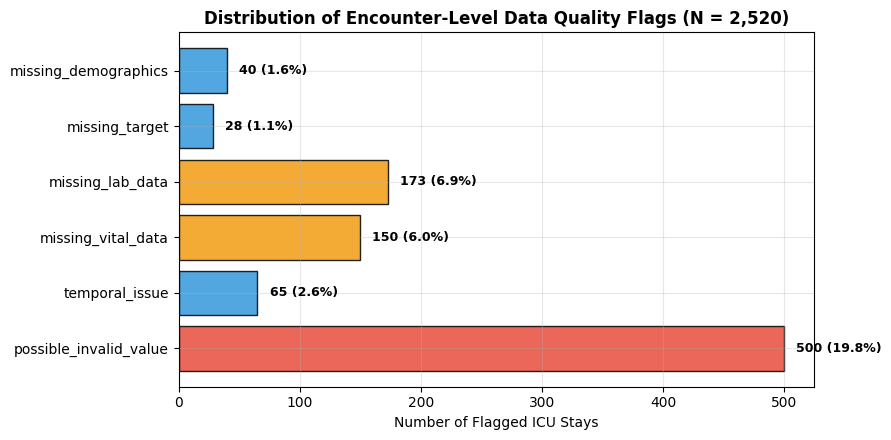

In [15]:
# Visualize Encounter Quality Flags
fig, ax = plt.subplots(figsize=(9, 4.5))

flag_names = [r["Quality Flag"].replace("flag_", "") for r in flag_summary_data]
flag_cts = [r["Flagged Stays"] for r in flag_summary_data]
colors = ["#e74c3c" if c > 300 else "#f39c12" if c > 100 else "#3498db" for c in flag_cts]

bars = ax.barh(flag_names[::-1], flag_cts[::-1], color=colors[::-1], edgecolor="black", alpha=0.85)
ax.set_title("Distribution of Encounter-Level Data Quality Flags (N = 2,520)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Flagged ICU Stays")

for bar in bars:
    w = bar.get_width()
    pct = (w / quality_flags.height) * 100
    ax.text(w + 10, bar.get_y() + bar.get_height()/2, f"{w:,} ({pct:.1f}%)", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


## 8. Validated Data Outputs & Phase 3 Transition

We persist the validated outputs with temporal and quality flags to `data/validated/` and generate a validation report in `reports/`:
- `data/validated/validated_patient.parquet`
- `data/validated/encounter_quality_flags.parquet`
- `data/validated/encounter_quality_flags.csv`
- `data/validated/validated_lab_temporal.parquet`
- `data/validated/validated_vital_temporal.parquet`
- `reports/validation_summary.md`
- `reports/metrics/validation_metrics.json`


In [16]:
from src.validation import run_full_validation_pipeline

# Execute end-to-end pipeline run
pipeline_results = run_full_validation_pipeline(
    data_dir=data_dir,
    output_dir=base_dir / "data" / "validated",
    reports_dir=base_dir / "reports"
)

print("Pipeline execution and artifact persistence complete!")


Validation completed successfully!
  • Validated data saved to: ..\data\validated
  • Reports saved to: ..\reports\validation_summary.md
Pipeline execution and artifact persistence complete!


### Phase 2 Validation Summary & Roadmap for Phase 3:

| Dimension Checked | Validation Finding | Action in Phase 3 (Feature Engineering) |
| :--- | :--- | :--- |
| **Schema & Keys** | All schemas valid; 0 duplicate primary keys; 0 orphan records. | Use `patientunitstayid` as the relational anchor. |
| **Outcome Target** | 8.51% mortality (212 expired vs. 2,280 alive); 28 unrecorded stays. | Filter 28 unlabelled stays from training sets; encode target binary `[0, 1]`. |
| **Temporal Observation** | 98,870 labs (22.8%) and 553,846 vitals (33.9%) in the 24h window. | Extract statistical aggregates (mean, min, max, std, trend) strictly from $0 \le \text{offset} \le 1440$. |
| **Physiological Artifacts** | Identified negative BPs (-44 to -76 mmHg) and out-of-bounds vitals in 500 stays. | Apply documented clinical boundary clipping/masking during feature extraction. |
| **Informative Missingness** | High missingness in arterial BPs (86.1%) and temp (93.1%) reflects clinical practice. | Create missingness indicators alongside imputed values; avoid complete-case deletion. |

---
**Phase 2 Complete.** Ready to proceed to **Phase 3: Feature Engineering** upon approval.
